# Initialization of the GCR ansatz for $H_2$

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pyscf.fci
import pyscf.lib

from xquces.hamiltonians import MolecularHamiltonianLinearOperator
from xquces import utils as xq_utils

pyscf.lib.num_threads(1)

1

In [ ]:
from xquces.gcr.igcr import IGCRSpinRestrictedParameterization
from xquces.states import hartree_fock_state

basis = "sto-3g"
bond_lengths = np.arange(0.4, 3.0, 0.1)
igcr_order = 2

energies = {
    "FCI": [],
    "HF": [],
    "CCSD": [],
    "iGCR2 seed": [],
}

for R in bond_lengths:
    mol = xq_utils.build_diatom("H", "H", float(R), basis, symmetry=False)
    mf = xq_utils.run_rhf(mol)
    ccsd = xq_utils.run_rccsd(mf)
    e_fci, _ = pyscf.fci.FCI(mol, mf.mo_coeff).kernel()

    hamiltonian = MolecularHamiltonianLinearOperator.from_scf(mf)
    norb = hamiltonian.norb
    nelec = hamiltonian.nelec

    reference = hartree_fock_state(norb, nelec)

    igcr = IGCRSpinRestrictedParameterization(
        norb=norb,
        nocc=nelec[0],
        order=igcr_order,
        layers=1
    )

    params = igcr.parameters_from_t_amplitudes(ccsd.t2, t1=ccsd.t1)
    state = igcr.ansatz_from_parameters(params).apply(reference, nelec, copy=True)

    energies["FCI"].append(float(e_fci))
    energies["HF"].append(float(mf.e_tot))
    energies["CCSD"].append(float(ccsd.e_tot))
    energies["iGCR2 seed"].append(float(hamiltonian.expectation(state)))

energies = {k: np.array(v) for k, v in energies.items()}

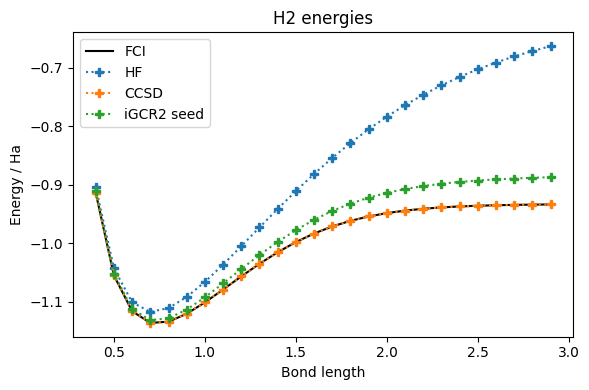

In [ ]:
plt.figure(figsize=(6, 4))

for label, E in energies.items():
    if label == "FCI":
        plt.plot(bond_lengths, E, label=label, color="black")
    else:
        plt.plot(bond_lengths, E, ':P', label=label)

plt.xlabel("Bond length")
plt.ylabel("Energy / Ha")
plt.title("H2 energies")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyscf.cc
import pyscf.fci
import ffsim

from xquces.gcr.igcr import IGCRSpinRestrictedParameterization
from xquces.states import hartree_fock_state


basis = "sto-6g"
bond_lengths = [1.2]
igcr_order = 2
layer_values = [1, 5, 10, 15, 20, 25, 30, 35, 40]

CHEM_ACC = 1.593601e-3  # Hartree

# N2 frozen core: freeze the two N 1s spatial orbitals.
n_frozen_core = 2

energies = {"R": [], "FCI": [], "HF": [], "CCSD": [],}

energies.update({f"iGCR{igcr_order} seed layers={k}": [] for k in layer_values})


for R in bond_lengths:
    R = float(R)
    print(f"\nR = {R:.2f} Å")
    mol = xq_utils.build_diatom("N", "N", R, basis, symmetry="Dooh")
    mf = xq_utils.run_rhf(mol)
    nmo_full = mf.mo_coeff.shape[1]
    active_space = range(n_frozen_core, nmo_full)

    mol_data = ffsim.MolecularData.from_scf(mf, active_space=active_space,)

    hamiltonian = mol_data.hamiltonian
    norb = mol_data.norb
    nelec = mol_data.nelec

    print(f"Full spatial orbitals:   {nmo_full}")
    print(f"Frozen spatial orbitals: {n_frozen_core}")
    print(f"Active spatial orbitals: {norb}")
    print(f"Active electrons:        {nelec}")

    ccsd = pyscf.cc.RCCSD(mf, frozen=n_frozen_core)
    ccsd.kernel()

    mol_data.run_fci()
    e_fci = float(mol_data.fci_energy)

    linop = ffsim.linear_operator( hamiltonian,norb=norb,nelec=nelec,)

    reference = hartree_fock_state(norb, nelec)

    energies["R"].append(R)
    energies["FCI"].append(e_fci)
    energies["HF"].append(float(mf.e_tot))
    energies["CCSD"].append(float(ccsd.e_tot))

    print(f"E_HF              = {mf.e_tot:.12f}")
    print(f"E_CCSD frozen     = {ccsd.e_tot:.12f}")
    print(f"E_FCI frozen-core = {e_fci:.12f}")

    for k in layer_values:
        igcr = IGCRSpinRestrictedParameterization(norb=norb, nocc=nelec[0], order=igcr_order, layers=k)
        params = igcr.parameters_from_t_amplitudes(ccsd.t2, t1=ccsd.t1)
        state = igcr.ansatz_from_parameters(params).apply(reference, nelec, copy=True,)
        e_seed = float(np.real(np.vdot(state, linop @ state)))
        key = f"iGCR{igcr_order} seed layers={k}"
        energies[key].append(e_seed)

        print(f"{key}: " f"E = {e_seed:.12f}, " f"abs error = {abs(e_seed - e_fci):.3e}")


df = pd.DataFrame(energies)

layer_values = np.array(layer_values)
layer_cols = [f"iGCR{igcr_order} seed layers={k}" for k in layer_values]
for _, row in df.iterrows():
    abs_errors = np.array([abs(row[col] - row["FCI"]) for col in layer_cols])
    plt.plot(layer_values,abs_errors, "--P", linewidth=2, label=fr"$R={row['R']:.2f}\ \AA$",)

plt.yscale("log")
plt.xlabel("Number of iGCR2 layers")
plt.ylabel(r"$|E_{\mathrm{iGCR2\ seed}} - E_{\mathrm{FCI}}|$ [Ha]")
plt.xticks(layer_values)
plt.grid(True, which="both", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


R = 1.20 Å
Full spatial orbitals:   10
Frozen spatial orbitals: 0
Active spatial orbitals: 10
Active electrons:        (7, 7)
Parsing /tmp/tmpzunwdhj5
converged SCF energy = -107.938194421902


/home/davido/micromamba/envs/py312/lib/python3.12/site-packages/pyscf/gto/mole.py:1293: UserWarning: Function mol.dumps drops attribute energy_nuc because it is not JSON-serializable
  warnings.warn(msg)
/home/davido/micromamba/envs/py312/lib/python3.12/site-packages/pyscf/gto/mole.py:1293: UserWarning: Function mol.dumps drops attribute intor_symmetric because it is not JSON-serializable
  warnings.warn(msg)


CASCI E = -108.727113223000  E(CI) = -130.335182668900  S^2 = 0.0000000
E_HF              = -108.535614528761
E_CCSD            = -108.721065409612
E_FCI             = -108.727113223000
iGCR2 seed layers=1: E = -108.664982166007, abs error = 6.213e-02
iGCR3 residual seed layers=1: E = -108.690805644992, abs error = 3.631e-02, accepted = 6/7, delta_sum = 1.078e-01, delta_max = 1.026e-01, last_delta = 0.000e+00, overlap_gain = 9.859e-03, rank = 16


KeyboardInterrupt: 